# Implementation

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# from validation_and_helpers import load_run
from non_markov_E_in_eigener_file import calculate_heom_propagator, _make_solver
from non_markov_circuit import propagate_memory_shots, propagate_memory_density_matrix, propagate_memory_classical

# Parameter

In [53]:
# ---- physical constants (energies in cm^-1, time tau = 2*pi*c*t in cm) ----
_C_CM = 2.99792458e10                    # speed of light [cm/s]
FS_TO_CM = 1e-15 * 2 * np.pi * _C_CM     # tau[cm] per t[fs]
KB_CM = 0.6950348004                     # Boltzmann constant [cm^-1/K]

N = 4                                    # 4-site (Seneviratne eq. 30) or 7-site FMO

if N == 4:
    H_FMO = np.array([[12375.0, -87.7,   5.5,  -5.9],
                      [-87.7, 12495.0,  30.8,   8.2],
                      [5.5,      30.8, 12175.0, -53.4],
                      [-5.9,      8.2, -53.4, 12285.0]])
elif N == 7:
    H_FMO = np.array([[1410.0, -87.7, 5.5, -5.9, 6.7, -13.7, -9.9],
                      [-87.7, 1530.0, 30.8, 8.2, 0.7, 11.8, 4.3],
                      [5.5, 30.8, 1210.0, -53.5, -2.2, -9.6, 6.0],
                      [-5.9, 8.2, -53.5, 1320.0, -70.7, -17.0, -63.3],
                      [6.7, 0.7, -2.2, -70.7, 1480.0, 81.1, -1.3],
                      [-13.7, 11.8, -9.6, -17.0, 81.1, 1630.0, 39.7],
                      [-9.9, 4.3, 6.0, -63.3, -1.3, 39.7, 1440.0]])
else:
    raise ValueError('N must be 4 or 7')

H_FMO = H_FMO - np.trace(H_FMO) / N * np.eye(N)
LAM_FMO, GAM_FMO, T_FMO = 3.0, 50.0, 300.0

# Bundled once and splatted into every method below, so HEOM and Lindblad are
# guaranteed to run on identical parameters.
MODEL = dict(H=H_FMO, lam=LAM_FMO, gamma=GAM_FMO, T_K=T_FMO,
             KB_CM=KB_CM, FS_TO_CM=FS_TO_CM)

K = 25
N = 4 
dt_fs = 10
t_fs = np.arange(0.0, 1001.0, dt_fs)      
HEOM_depth = 3

In [54]:
# Initialisiere globales Dictionary (falls noch nicht vorhanden)
if 'out_B' not in globals():
    out_B = {}

M_KRYLOV = 53

# Calculate

### Startzustände

In [55]:
# 1. Propagator E und die berechneten Kurzzeit-Karten holen
E, K, maps = calculate_heom_propagator(dt_fs, HEOM_depth=HEOM_depth, K_heom=K, N=N, **MODEL)

# 2. Vektorisierter Startzustand rho(0)
rho0_vec = np.zeros(N * N, complex)
rho0_vec[0] = 1.0  # Anregung auf Site 1

# 3. Exakte Historie der ersten K Schritte via L(t) * rho0 berechnen
rho_history = [maps[i] @ rho0_vec for i in range(K)]

# 4. Physikalischen Super-Vektor X0 zusammensetzen:
# rho(t_{K-1}) liegt ganz oben (Index 0), rho(t_0) ganz unten
X0 = np.concatenate(rho_history[::-1])

### Exaktes Ergebnis mit qutip

In [56]:
import qutip as qt
import time

# 1. Startzustand als QuTiP Qobj definieren (Anregung auf Site 1)
rho0_qt = qt.Qobj(np.diag([1.0] + [0.0] * (N - 1)))

# 2. Zeitachse in die physikalischen Einheiten (cm) umwandeln, die der Solver nutzt
t_cm = t_fs * MODEL['FS_TO_CM']

print("Starte exakte QuTiP HEOM Propagation")
start_time = time.time()

# 3. Solver instanziieren (nutzt deine bereits vorhandene Funktion)
solver = _make_solver(H=MODEL['H'], lam=MODEL['lam'], gamma=MODEL['gamma'], 
                      T_K=MODEL['T_K'], KB_CM=MODEL['KB_CM'], Nk=1, depth=HEOM_depth)

# 4. Solver über die gesamte Zeitachse ausführen
result = solver.run(rho0_qt, t_cm)

# 5. Populationen (Diagonalelemente) extrahieren
pops_qutip = np.zeros((len(t_fs), N))
for i, state in enumerate(result.states):
    pops_qutip[i, :] = np.real(state.diag())
    
print(f"QuTiP Propagation abgeschlossen in {time.time() - start_time:.2f} Sekunden.")

# In das globale Dictionary einspeichern
# (Wir übergeben None für qc und info, da dies eine rein klassische Referenz ist)
out_B['HEOM_exakt (QuTiP)'] = (pops_qutip, None, None)

Starte exakte QuTiP HEOM Propagation
10.0%. Run time:   0.03s. Est. time left: 00:00:00:00
20.0%. Run time:   0.06s. Est. time left: 00:00:00:00
30.0%. Run time:   0.09s. Est. time left: 00:00:00:00
40.0%. Run time:   0.11s. Est. time left: 00:00:00:00
50.0%. Run time:   0.14s. Est. time left: 00:00:00:00
60.0%. Run time:   0.17s. Est. time left: 00:00:00:00
70.0%. Run time:   0.20s. Est. time left: 00:00:00:00
80.0%. Run time:   0.22s. Est. time left: 00:00:00:00
90.0%. Run time:   0.24s. Est. time left: 00:00:00:00
100.0%. Run time:   0.26s. Est. time left: 00:00:00:00
Total run time:   0.26s
QuTiP Propagation abgeschlossen in 0.29 Sekunden.


### Exaktes Ergebnis mit Fensterlänge K aber ohne Krylov

In [57]:
D_dim = N * N
n_steps_total = len(t_fs) - 1
exact_pops = np.zeros((n_steps_total + 1, N))

# Die ersten K Schritte (0 bis K-1) direkt aus der berechneten Historie befüllen:
for i in range(K):
    exact_pops[i, :] = np.real(np.diag(rho_history[i].reshape((N, N), order='F')))
out_B['HEOM_nur_fenster_kein_krylov'] = (exact_pops, None, None)

# Ab Schritt K propagieren wir den Zustand klassisch mit E weiter:
X_curr = X0.copy()
for t in range(K, n_steps_total + 1):
    X_curr = E @ X_curr
    exact_pops[t, :] = np.real(np.diag(X_curr[:D_dim].reshape((N, N), order='F')))

res = {
    'HEOM': {
        'E': E,
        'K': K,
        'pops': exact_pops,
        'rho': [r.reshape((N, N), order='F') for r in rho_history]
    }
}
print(f"Max Abweichung zum QuTiP-Solver: {np.abs(exact_pops - pops_qutip).max():.2e}")

Max Abweichung zum QuTiP-Solver: 5.58e-03


### Ohne circuit mit Krylov und Fenster

In [58]:
entry_name = 'HEOM_ohne_circuit (Krylov + Fenster)'

# Aufruf
pops_class, _, info_class = propagate_memory_classical(E, X0, len(t_fs) - K, M_KRYLOV, N)
out_B[entry_name] = (pops_class, None, info_class)

# Vergleich mit der gespeicherten Referenz
print(f"Max Abweichung zum Qutip Solver(ab t_{{K-1}}): {np.abs(pops_qutip[K - 1:] - res['HEOM']['pops'][K - 1:]).max():.2e}")

Max Abweichung zum Qutip Solver(ab t_{K-1}): 5.58e-03


### Density Matrix auf circuit (Krylov + Fenster)

In [36]:
if __name__ == '__main__':
      source_name = 'HEOM'
      entry_name = 'HEOM_density_matrix (Krylov + Fenster)'


      # 2. Den echten physikalischen Super-Vektor X0 aufbauen
      rho0_vec = np.zeros(N * N, complex)
      rho0_vec[0] = 1.0  # Anregung startet auf Site 1

      # Die echten Zustände der ersten K Schritte berechnen
      rho_history = [maps[i] @ rho0_vec for i in range(K)]

      # Zum Vektor X0 zusammensetzen (ältester Zustand unten)
      X0 = np.concatenate(rho_history[::-1])

      # 3. Aufruf der deterministischen Dichtematrix-Funktion mit dem KORREKTEN X0
      pops, qc, info = propagate_memory_density_matrix(E, X0, len(t_fs) - K, M_KRYLOV, N)
      out_B[entry_name] = (pops, qc, info)

      full_reg = E.shape[0]
      print(f"{entry_name:14s} register {full_reg} -> {info['m']} (Krylov), {info['n_qubits']} qubits, depth {qc.depth()}")
      print(f"{'':14s} ||H_m|| = {info['norm_Hm']:.4f}, p_success = {info.get('p_success', 1.0):.3e} ({1 / info.get('p_success', 1.0):.1f} shots/sample), "
            f"naive would be {(1 / np.linalg.norm(E, 2) ** 2) ** (len(t_fs) - K):.1e}")
      print(f"Max Abweichung zum Qutip Solver(ab t_{{K-1}}): {np.abs(pops_qutip[K - 1:] - pops).max():.2e}")

HEOM_density_matrix (Krylov + Fenster) register 400 -> 53 (Krylov), 7 qubits, depth 228
               ||H_m|| = 1.0287, p_success = 6.836e-03 (146.3 shots/sample), naive would be 1.3e-23
Max Abweichung zum Qutip Solver(ab t_{K-1}): 4.28e-02


### Shots auf circuit (Krylov + Fenster)

In [37]:
### Shots auf circuit (Krylov + Fenster)
if __name__ == '__main__':
    name = 'HEOM_shots (Krylov + Fenster)'

    pops, qc, info = propagate_memory_shots(E, X0, len(t_fs) - K, M_KRYLOV, N)
    out_B[name] = (pops, qc, info)

    n_calculated = len(pops)
    full_reg = E.shape[0]
    print(f"{name:14s} register {full_reg} -> {info['m']} (Krylov), {info['n_qubits']} qubits, depth {qc.depth()}")
    print(f"{'':14s} ||H_m|| = {info['norm_Hm']:.4f}, p_success = {info['p_success']:.3e} ({1 / info['p_success']:.1f} shots/sample), "
          f"naive would be {(1 / np.linalg.norm(E, 2) ** 2) ** (len(t_fs) - K):.1e}")
    
    # Slicing fängt auch abbrechende Simulationen sauber ab:
    print(f"Max Abweichung zum Qutip Solver (bis t={K - 1 + n_calculated - 1}): "
          f"{np.abs(pops_qutip[K - 1 : K - 1 + n_calculated] - pops).max():.2e}\n")

Zeitschritt 76/76
HEOM_shots (Krylov + Fenster) register 400 -> 53 (Krylov), 7 qubits, depth 228
               ||H_m|| = 1.0287, p_success = 6.200e-03 (161.3 shots/sample), naive would be 1.3e-23
Max Abweichung zum Qutip Solver (bis t=100): 3.67e-02



# Plotting

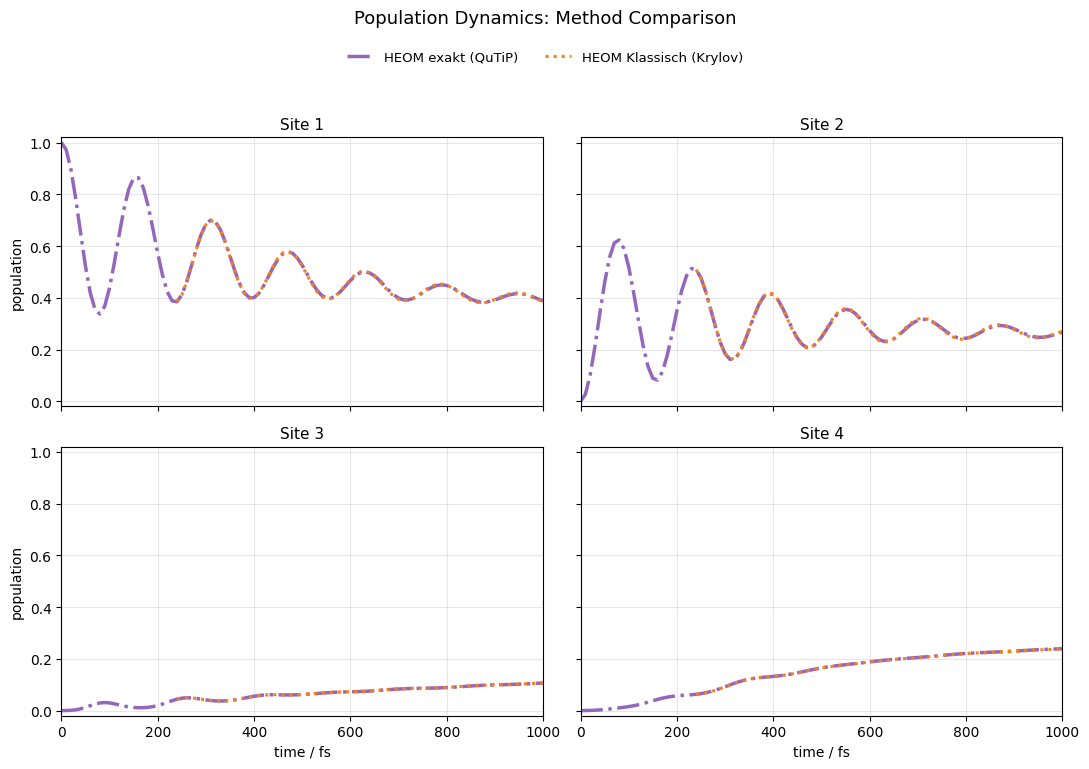

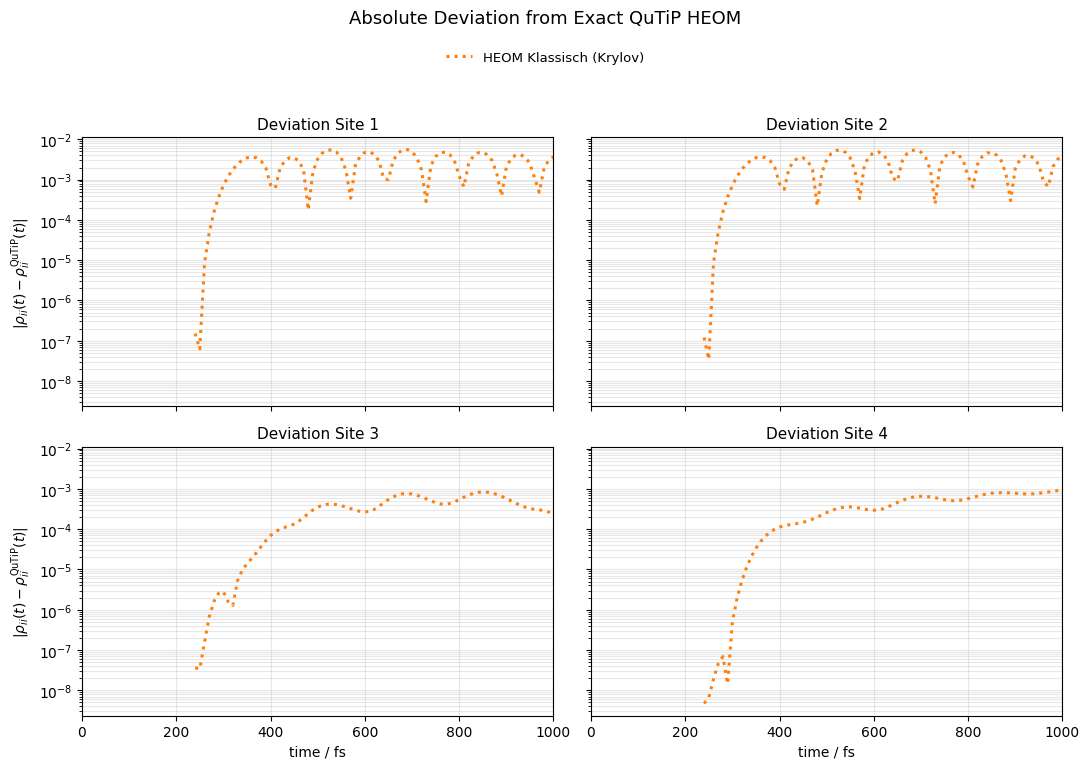

In [59]:
if __name__ == '__main__':
    import matplotlib.pyplot as plt
    from matplotlib.lines import Line2D
    import numpy as np

    # 1. Namen exakt so wie in out_B definiert:
    plot_methods = [
        'HEOM_exakt (QuTiP)',
        #'HEOM_nur_fenster_kein_krylov',
        'HEOM_ohne_circuit (Krylov + Fenster)',
        #'HEOM_density_matrix (Krylov + Fenster)',
        #'HEOM_shots (Krylov + Fenster)',              # <-- Vollständiger Name
    ]

    style_config = {
        'HEOM_exakt (QuTiP)':                     {'color': '#9467bd', 'ls': '-.', 'lw': 2.5, 'marker': None, 'label': 'HEOM exakt (QuTiP)'},
        'HEOM_nur_fenster_kein_krylov':           {'color': '#000000', 'ls': '--', 'lw': 1.6, 'marker': None, 'label': 'HEOM (Nur Fenster)'},
        'HEOM_ohne_circuit (Krylov + Fenster)':   {'color': '#ff7f0e', 'ls': ':',  'lw': 2.2, 'marker': None, 'label': 'HEOM Klassisch (Krylov)'},
        'HEOM_density_matrix (Krylov + Fenster)': {'color': '#2ca02c', 'ls': '-',  'lw': 1.8, 'marker': None, 'label': 'HEOM Circuit (Density Matrix)'},
        'HEOM_shots (Krylov + Fenster)':          {'color': '#d62728', 'ls': 'None', 'lw': 1.0, 'marker': 'o', 'ms': 3.5, 'label': 'HEOM Circuit (Shots)'}
    }

    # ==========================================================================
    # FIGURE 1: Trajektorien
    # ==========================================================================
    fig1, axes1 = plt.subplots(2, 2, figsize=(11, 7.5), sharex=True, sharey=True)

    for site, ax in enumerate(axes1.flat):
        for name in plot_methods:
            if name not in out_B:
                continue
            
            pops_data = out_B[name][0]
            cfg = style_config[name]
            n_points = len(pops_data)
            
            # Dynamische Zeitachse passend zur Datenlänge:
            if n_points == len(t_fs):
                t_plot = t_fs
            else:
                # Startet ab t_{K-1} und geht genau n_points Schritte weit
                t_plot = t_fs[K - 1 : K - 1 + n_points]
            
            if cfg['marker']:
                ax.plot(t_plot, pops_data[:, site], color=cfg['color'], 
                        marker=cfg['marker'], ls=cfg['ls'], markersize=cfg['ms'], alpha=0.8)
            else:
                ax.plot(t_plot, pops_data[:, site], color=cfg['color'], 
                        ls=cfg['ls'], lw=cfg['lw'])
            
        ax.set_title(f'Site {site + 1}', fontsize=11)
        ax.set_xlim(0, t_fs[-1])
        ax.set_ylim(-0.02, 1.02)
        ax.grid(alpha=0.3)
        if site >= 2: 
            ax.set_xlabel('time / fs')
        if site % 2 == 0: 
            ax.set_ylabel('population')

    handles1 = []
    for name in plot_methods:
        if name in out_B:
            cfg = style_config[name]
            if cfg['marker']:
                handles1.append(Line2D([], [], color=cfg['color'], marker=cfg['marker'], 
                                       ls=cfg['ls'], markersize=cfg['ms'] + 2, label=cfg['label']))
            else:
                handles1.append(Line2D([], [], color=cfg['color'], ls=cfg['ls'], 
                                       lw=cfg['lw'], label=cfg['label']))

    fig1.legend(handles=handles1, loc='upper center', ncol=3, frameon=False, fontsize=9.5, bbox_to_anchor=(0.5, 0.98))
    fig1.suptitle('Population Dynamics: Method Comparison', fontsize=13, y=1.02)
    fig1.tight_layout(rect=[0, 0, 1, 0.94])

    # ==========================================================================
    # FIGURE 2: Absolute Abweichung zur QuTiP-Referenz
    # ==========================================================================
    if 'HEOM_exakt (QuTiP)' in out_B:
        fig2, axes2 = plt.subplots(2, 2, figsize=(11, 7.5), sharex=True, sharey=True)
        qutip_pops = out_B['HEOM_exakt (QuTiP)'][0]
        
        for site, ax in enumerate(axes2.flat):
            for name in plot_methods:
                if name not in out_B or name == 'HEOM_exakt (QuTiP)':
                    continue
                
                pops_data = out_B[name][0]
                cfg = style_config[name]
                n_points = len(pops_data)
                
                if n_points == len(t_fs):
                    t_plot = t_fs
                    error = np.abs(pops_data[:, site] - qutip_pops[:, site])
                else:
                    t_plot = t_fs[K - 1 : K - 1 + n_points]
                    error = np.abs(pops_data[:, site] - qutip_pops[K - 1 : K - 1 + n_points, site])
                
                error = np.where(error <= 1e-16, 1e-16, error)
                
                if cfg['marker']:
                    ax.plot(t_plot, error, color=cfg['color'], 
                            marker=cfg['marker'], ls=cfg['ls'], markersize=cfg['ms'], alpha=0.8)
                else:
                    ax.plot(t_plot, error, color=cfg['color'], 
                            ls=cfg['ls'], lw=cfg['lw'])
            
            ax.set_title(f'Deviation Site {site + 1}', fontsize=11)
            ax.set_xlim(0, t_fs[-1])
            ax.set_yscale('log')
            ax.grid(alpha=0.3, which='both')
            if site >= 2: 
                ax.set_xlabel('time / fs')
            if site % 2 == 0: 
                ax.set_ylabel(r'$|\rho_{ii}(t) - \rho_{ii}^{\mathrm{QuTiP}}(t)|$')

        handles2 = [h for h in handles1 if 'QuTiP' not in h.get_label()]
        fig2.legend(handles=handles2, loc='upper center', ncol=2, frameon=False, fontsize=9.5, bbox_to_anchor=(0.5, 0.98))
        fig2.suptitle('Absolute Deviation from Exact QuTiP HEOM', fontsize=13, y=1.02)
        fig2.tight_layout(rect=[0, 0, 1, 0.94])

    plt.show()

In [61]:
qc.draw()

»
   sys_0: »
          »
   sys_1: »
          »
   sys_2: »
          »
   sys_3: »
          »
   sys_4: »
          »
   sys_5: »
          »
     anc: »
          »
c_anc: 76/»
          »
«          ┌──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐»
«   sys_0: ┤0                                                                                                                                                                                                                                                                             ├»
«          │                                                                                                                                                                                                                                                                              │»
«   sys_1: ┤1                                                                                                                                                                                                                                                                             ├»
«          │                                                                                                                                                                                                                                                                              │»
«   sys_2: ┤2                                                                                                                                                                                                                                                                             ├»
«          │                                                                                                                                                                                                                                                                              │»
«   sys_3: ┤3 Initialize(1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0) ├»
«          │                                                                                                                                                                                                                                                                              │»
«   sys_4: ┤4                                                                                                                                                                                                                                                                             ├»
«          │                                                                                                                                                                                                                                                                              │»
«   sys_5: ┤5                                                                                                                                                                                                                                                                             ├»
«          │                                                                                                                                                                                                                                                                              │»
«     anc: ┤6                                                                                        